In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y

def exact_solution(x):
    return np.exp(-2 * x)

def solve_euler(h, x_start, x_end, y0):
    num_steps = int((x_end - x_start) / h)
    x_vals = np.linspace(x_start, x_end, num_steps + 1)
    y_vals = np.zeros(num_steps + 1)
    y_vals[0] = y0
    
    for i in range(num_steps):
        y_vals[i + 1] = y_vals[i] + h * f(x_vals[i], y_vals[i])
    
    return x_vals, y_vals

# Parameters
h_values = [0.1, 0.5, 1.0, 1.5]
x_start, x_end = 0, 10
y0 = 1

h = 0.1 | Local Error: 0.0187 | Global Error: 1.8575e-09
h = 0.5 | Local Error: 0.3679 | Global Error: 2.0612e-09
h = 1.0 | Local Error: 1.1353 | Global Error: 1.0000e+00
h = 1.5 | Local Error: 2.0498 | Global Error: 6.4000e+01


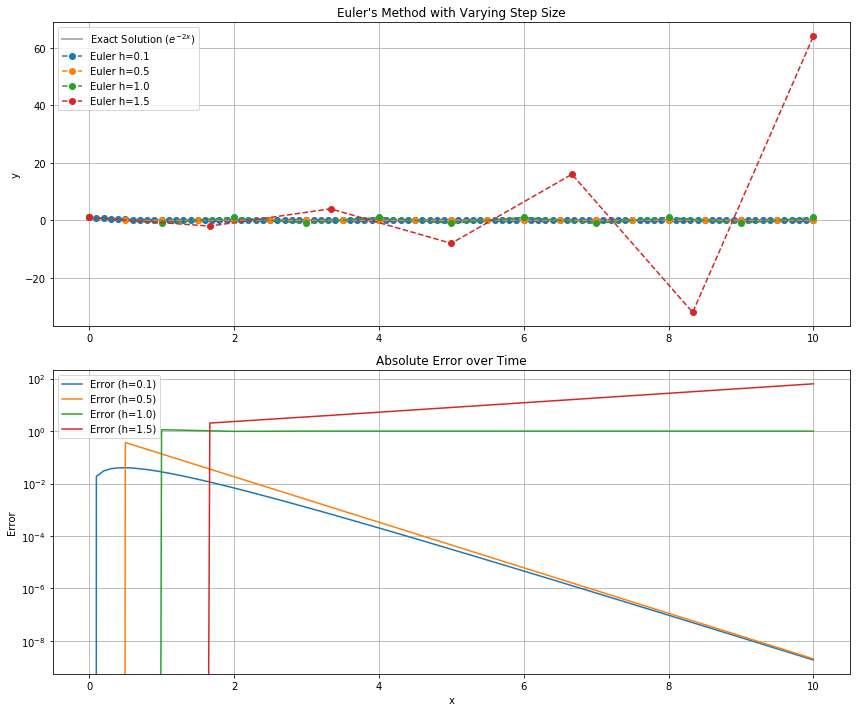

In [3]:
# Defining the subplots a single tome before the loop rather than multiple times to prevent an error---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot the Exact Solution once on the top plot
x_fine = np.linspace(x_start, x_end, 500)
ax1.plot(x_fine, exact_solution(x_fine), 'k', lw=2, label="Exact Solution ($e^{-2x}$)", alpha=0.3)

for h in h_values:
    x_vals, y_vals = solve_euler(h, x_start, x_end, y0)
    y_exact = exact_solution(x_vals)
    
    # Calculate Errors
    local_error = np.abs((y0 + h * f(0, y0)) - exact_solution(h))
    global_error = np.abs(y_vals[-1] - exact_solution(x_end))
    
    print(f"h = {h:.1f} | Local Error: {local_error:.4f} | Global Error: {global_error:.4e}")
    
    # --- FIX: Use ax1 and ax2 to plot inside the loop ---
    ax1.plot(x_vals, y_vals, 'o--', label=f"Euler h={h}")
    ax2.plot(x_vals, np.abs(y_vals - y_exact), label=f"Error (h={h})")

# Final Formatting (Outside the loop)
ax1.set_title("Euler's Method with Varying Step Size")
ax1.set_ylabel("y")
ax1.legend()
ax1.grid(True)

ax2.set_title("Absolute Error over Time")
ax2.set_xlabel("x")
ax2.set_ylabel("Error")
ax2.set_yscale('log') 
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Write up

1. When does it become unstable? Is it becoming unstable?:

It is becoming unstable at h=1.5. Although it is becoming unstable, the degree that it is becoming unstable at is at different rates as the h value changes. At h = 0.01, with the number of iterations, the error is small. This is the case until h=1.5 where the error gets out of control and becomes unstable. However, if we let the simulation run long enough (like to t = 100 for example), we would see the peaks of the wave getting taller for all h values.

2. Playing with K: What are you seeing?

With K (i.e. the spring constant), higher values makes the 'spring' stiffer and the oscillations faster. In addition to that, as k increases, the period of the sine wave decreases, the frequency increases, and the sine wave gets tighter.

3. Setting k = 10, h = 0.01

At k = 10, the frequency is $\omega = \sqrt{10} \approx 3.16$. With h = 0.01, the code is taking about ~200 steps per oscillation. This will resukt in a very clean, stable sine wave for the first few seconds. However, the underlying "energy pumping" is still there, it’s just much smaller due to the small h value.

4. Can Euler solve this with a larger h?

Not really. the Forward Euler method is generally the wrong tool for oscillating systems if a large step size is reuqired due to instablilty. If we want to simultaneously use a larger h and keep the system stable, we would need a Symplectic Integrator, such as the Semi-Implicit Euler (or Euler-Cromer).